# Figure 2 Supplementary — two figures, plot-data-only cache

This version preserves **both** figures from the original notebook:

1. **Ripple figure:** patient-wise mean ripple trace (black) with 95% CI shading.
2. **Spike figure:** individual spike traces (gray) with the patient-wise mean trace (red).

Only the final data needed to redraw those figures are cached.

- Ripple figure cache: `mean_trace`, `ci95`, `n`, patient title.
- Spike figure cache: `spike_traces`, `avg_trace`, `n`, patient title.

After the first run, no raw `.mat` files or spike-label files need to be read again.


In [1]:
# ============================================================
# PLOT ONLY LOADER — START HERE AFTER THE FIRST RUN
#
# No raw .mat loading
# No label reconstruction
# No upstream computation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

CACHE_FILE = "Figure2_Suppl_two_figures_plot_inputs.npz"

with np.load(CACHE_FILE, allow_pickle=False) as cached:
    trace_length = int(cached["trace_length"])
    ripple_ylim = cached["ripple_ylim"]
    spike_ylim = cached["spike_ylim"]

    ripple_patient_ids = cached["ripple_patient_ids"]
    ripple_patient_titles = cached["ripple_patient_titles"]

    spike_patient_ids = cached["spike_patient_ids"]
    spike_patient_titles = cached["spike_patient_titles"]

    ripple_plot_data = []
    for patient, title in zip(ripple_patient_ids, ripple_patient_titles):
        ripple_plot_data.append(
            (
                patient,
                title,
                cached[f"ripple_mean__{patient}"].copy(),
                cached[f"ripple_ci95__{patient}"].copy(),
                int(cached[f"ripple_n__{patient}"]),
            )
        )

    spike_plot_data = []
    for patient, title in zip(spike_patient_ids, spike_patient_titles):
        spike_plot_data.append(
            (
                patient,
                title,
                cached[f"spike_traces__{patient}"].copy(),
                cached[f"spike_avg__{patient}"].copy(),
                int(cached[f"spike_n__{patient}"]),
            )
        )

print(f"Loaded: {CACHE_FILE}")
print(f"Ripple panels: {len(ripple_plot_data)}")
print(f"Spike panels:  {len(spike_plot_data)}")


Loaded: Figure2_Suppl_two_figures_plot_inputs.npz
Ripple panels: 17
Spike panels:  15


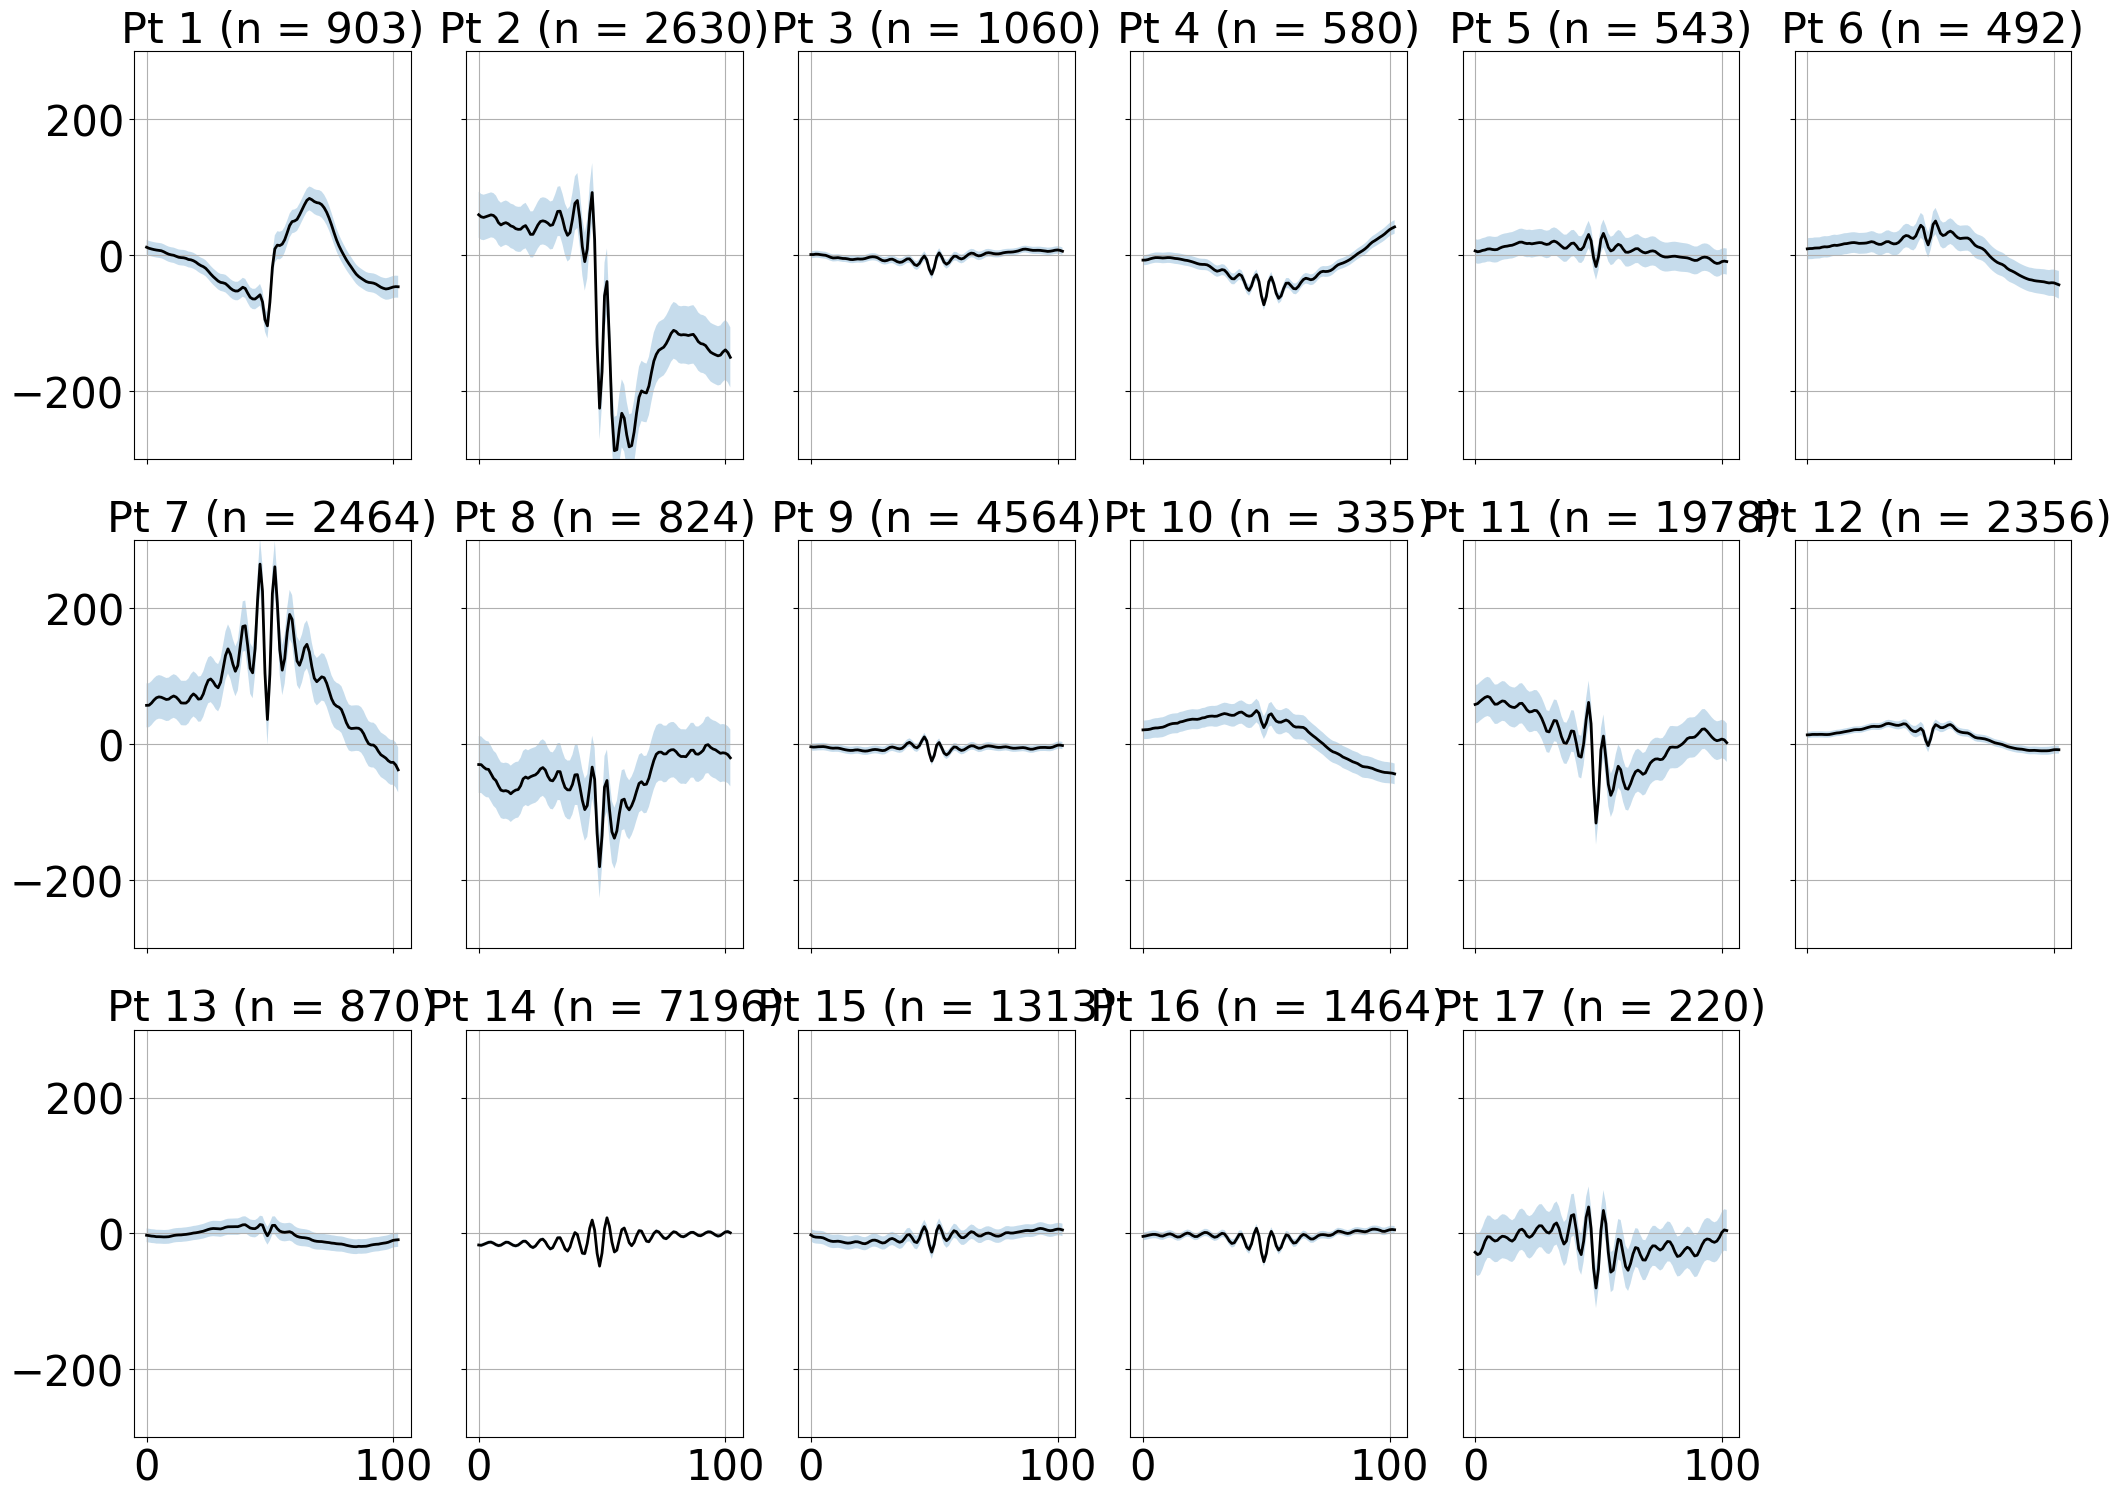

In [2]:
# ============================================================
# FIGURE 1 — RIPPLE PLOT ONLY
# Mean ripple trace (black) + 95% CI
# ============================================================

fig, axs = plt.subplots(
    3, 6,
    figsize=(25, 18),
    sharex=True,
    sharey=True
)
axs = axs.ravel()

x = np.arange(trace_length)

for count, (patient, title, mean_trace, ci95, n_ripple) in enumerate(ripple_plot_data):
    ax = axs[count]

    ax.plot(
        x,
        mean_trace,
        color="black",
        linewidth=2
    )

    ax.fill_between(
        x,
        mean_trace - ci95,
        mean_trace + ci95,
        alpha=0.25
    )

    ax.grid(True)
    ax.set_ylim(ripple_ylim)

    # Keep n visible; remove " (n=...)" here if you want
    # the exact final title behavior of the old cell.
    ax.set_title(
        f"{title} (n = {n_ripple})",
        fontsize=31
    )

    ax.tick_params(axis="x", labelsize=30)
    ax.tick_params(axis="y", labelsize=30)

for idx in range(len(ripple_plot_data), len(axs)):
    axs[idx].axis("off")

plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.show()


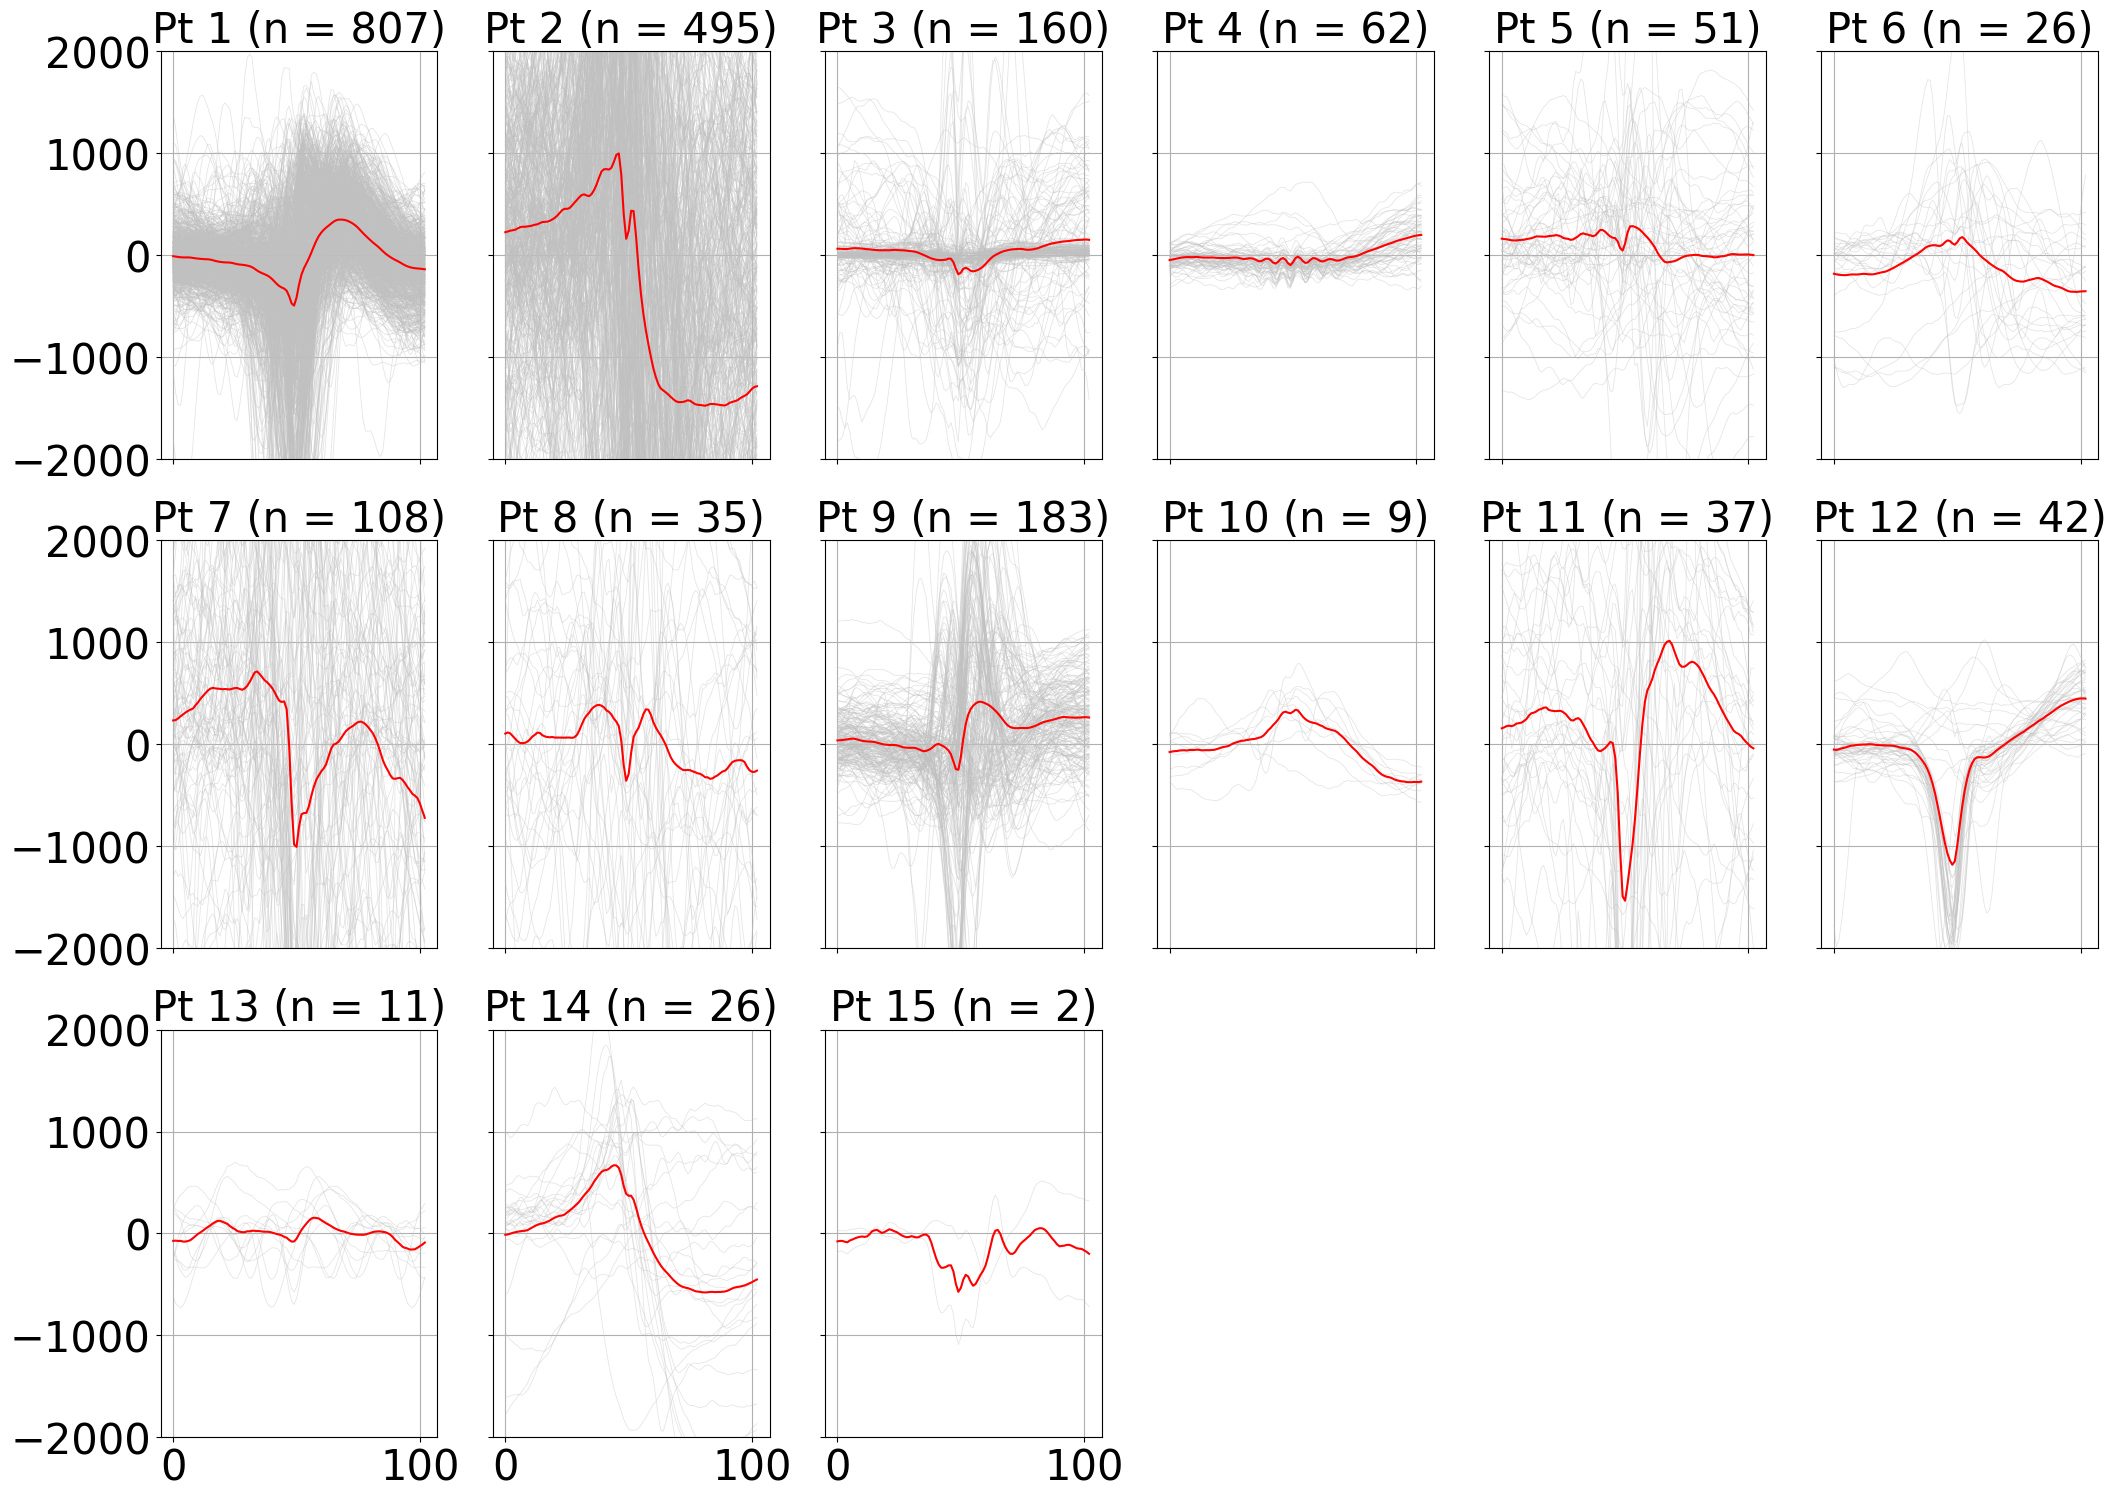

In [3]:
# ============================================================
# FIGURE 2 — SPIKE PLOT ONLY
# Individual spike traces (gray) + mean trace (red)
# ============================================================

fig, axs = plt.subplots(
    3, 6,
    figsize=(25, 18),
    sharex=True,
    sharey=True
)
axs = axs.ravel()

x = np.arange(trace_length)

for count, (patient, title, spike_traces, avg_trace, n_spike) in enumerate(spike_plot_data):
    ax = axs[count]

    for each_trace in spike_traces:
        ax.plot(
            x,
            each_trace,
            color="silver",
            linewidth=0.6,
            alpha=0.4
        )

    ax.plot(
        x,
        avg_trace,
        color="red"
    )

    ax.grid(True)
    ax.set_ylim(spike_ylim)
    ax.set_title(
        f"{title} (n = {n_spike})",
        fontsize=30
    )

    ax.tick_params(axis="x", labelsize=30)
    ax.tick_params(axis="y", labelsize=30)

for idx in range(len(spike_plot_data), len(axs)):
    axs[idx].axis("off")

plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.show()
